> **Traçabilité (fusion Codes_finaux) :** notebook présent uniquement dans `Codes prof/MNIST_3_CNN_PyTorch.ipynb` (pas d'équivalent Colab), copié tel quel.

---
# CNN : `MNIST` (avec `PyTorch`)
---

## Packages

In [ ]:
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms

---
## 1. Données
---

### 1.1. Importation et normalisation

In [2]:
test_portion = 1/5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x / 255)
])

data_train_valid = datasets.MNIST('./data', train=True, download=True, transform=transform)
data_test        = datasets.MNIST('./data', train=False, download=True, transform=transform)

size_valid = int(len(data_train_valid) * test_portion)
size_train = len(data_train_valid) - size_valid

data_train, data_valid = random_split(data_train_valid, [size_train, size_valid])

loader_train = DataLoader(data_train, batch_size=64, shuffle=True)
loader_valid = DataLoader(data_valid, batch_size=64, shuffle=False)
loader_test  = DataLoader(data_test,  batch_size=64, shuffle=False)

### 1.2 .Graphiques

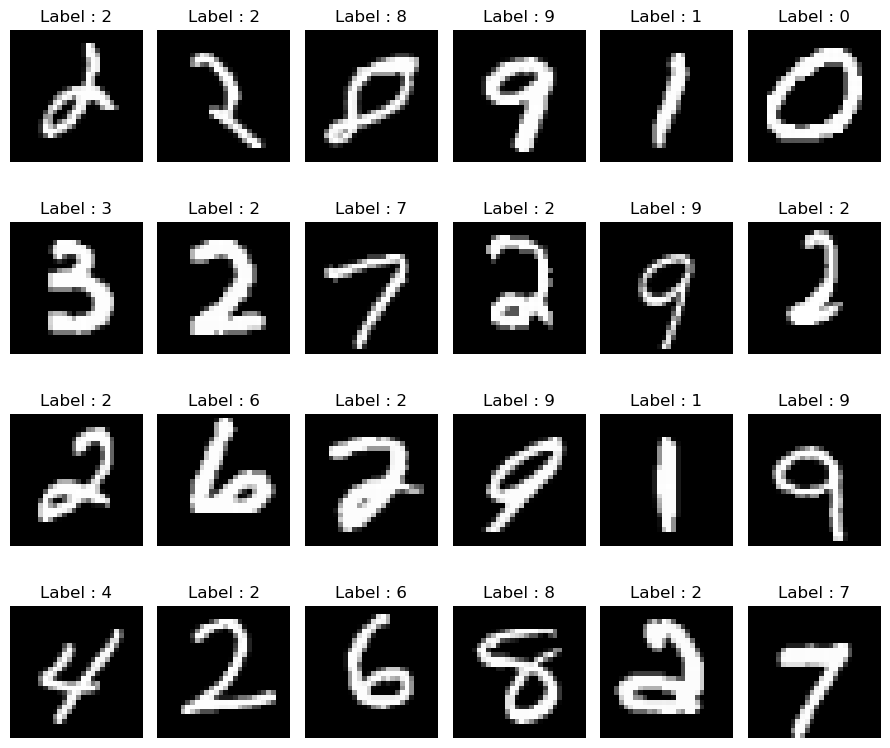

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

data_iter = iter(loader_train)
images, labels = next(data_iter)

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i].squeeze(0), cmap='gray')
    ax.set_title(f'Label : {labels[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 2. CNN
---

### 2.1. Architecture

In [4]:
dim_outputs = 10

filt_conv1 = 8
filt_conv2 = 16

dropout_conv = 0.2

n_units_hl = 100
dropout_hl = 0.2

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, filt_conv1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(filt_conv1, filt_conv2, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(dropout_conv)
        self.fc1 = nn.Linear(filt_conv2 * 7 * 7, n_units_hl)
        self.fc1_dropout = nn.Dropout(dropout_hl)
        self.fc2 = nn.Linear(n_units_hl, dim_outputs)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

### 2.2. Entraînement

In [5]:
n_epochs_max = 100
patience     = 5

class EarlyStopping:
    def __init__(self, patience=5, delta=0, path='best_model.pth'):
        self.patience = patience
        self.delta = delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False
        self.path = path
    
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def train_model(model, loader_train, loader_valid, epochs=20, lr=0.001, patience=3):
    model.to(device)
    #optimizer = optim.Adam(model.parameters(), lr=lr)
    optimizer = optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=3)
    
    for epoch in range(epochs):
        model.train()
        loss_train = 0
        for images, labels in loader_train:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            loss_train += loss.item()
        
        model.eval()
        loss_valid = 0
        with torch.no_grad():
            for images, labels in loader_valid:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss_valid += loss.item()
        
        print(f'Epoque {epoch+1}, Entropie train: {loss_train/len(loader_train):.4f}, Entropie valid: {loss_valid/len(loader_valid):.4f}')
        
        early_stopping(loss_valid, model)
        if early_stopping.early_stop:
            print('Early stopping')
            model.load_state_dict(torch.load(early_stopping.path, weights_only=True))
            break

model = CNN()
train_model(model, loader_train, loader_valid, epochs=n_epochs_max, patience=patience)

Epoque 1, Entropie train: 2.3018, Entropie valid: 2.3017
Epoque 2, Entropie train: 2.3013, Entropie valid: 2.3011
Epoque 3, Entropie train: 1.5718, Entropie valid: 0.6106
Epoque 4, Entropie train: 0.5849, Entropie valid: 0.3273
Epoque 5, Entropie train: 0.3902, Entropie valid: 0.2507
Epoque 6, Entropie train: 0.3307, Entropie valid: 0.2161
Epoque 7, Entropie train: 0.3006, Entropie valid: 0.2023
Epoque 8, Entropie train: 0.2799, Entropie valid: 0.1813
Epoque 9, Entropie train: 0.2588, Entropie valid: 0.1734
Epoque 10, Entropie train: 0.2518, Entropie valid: 0.1602
Epoque 11, Entropie train: 0.2362, Entropie valid: 0.1544
Epoque 12, Entropie train: 0.2275, Entropie valid: 0.1504
Epoque 13, Entropie train: 0.2175, Entropie valid: 0.1444
Epoque 14, Entropie train: 0.2117, Entropie valid: 0.1397
Epoque 15, Entropie train: 0.2004, Entropie valid: 0.1473
Epoque 16, Entropie train: 0.1957, Entropie valid: 0.1315
Epoque 17, Entropie train: 0.1902, Entropie valid: 0.1304
Epoque 18, Entropie tra

### 2.3. Prévisions

In [6]:
def test_model(model, loader_test):
    model.load_state_dict(torch.load('best_model.pth', weights_only=True))
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader_test:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f'Exactitude test: {100 * correct / total:.2f}%')

test_model(model, loader_test)

Exactitude test: 97.63%
